# Lab: Advanced Sequential Modeling

**Course:** Deep Learning: Advanced Models and Methods

**Instructor:** Antonino Furnari

**Duration:** 2 Hours (In-class Group Lab)

## 📝 Lab Format & Deliverables
* **Format:**
  * Students work in groups of 1-3.
  * The teacher gives a brief introduction to the lab, then students work independently with support from the teacher.
* **Strategy:**
  * Fill in the ☑️ `TODO` blocks. Do not modify the provided boilerplate unless necessary.
  * Fill in the short 📝 `Reflections` where required.
* **Submission:**
  * Fill in this notebook and send it to <antonino.furnari@unict.it> as an `.ipynb` by the end of the lab
* **Grading:**
  * Notebooks will be graded in binary way as passed / not passed based on completion (did the group reach all milestones successfully? are reflections adequate?)
  * Each notebook is worth $0.5$ bonus points. These are assigned to students individually (not to groups).
* **Computation:**
  * Run this notebook on Google Colab or Kaggle with GPU acceleration.

You will find the following blocks throughout the notebook:

> ☑️ **TODO**
>
> This box provides you instruction on a TODO that should be completed in the code cells below.

> 📝 **Reflection**
>
> You are required to write a short reflection on your results.


## Your Data
> 📝 **Date and Team Composition**
>
> <i>Insert the current date, plus names, surnames, matricola, and emails of the team members below:</i>
>
> **Date:** YYYY-MM-DD
>
> **Link to wandb:** <a href="example_link">link</a>
>
> | Name | Surname | Matricola | Email |
> |---|---:|---:|---|
> | Name 1 | Surname1 | 0000001 | <a href="mailto:member1@example.com">member1@example.com</a> |
> | Name 2 | Surname2 | 0000002 | <a href="mailto:member2@example.com">member2@example.com</a> |
> | Name 3 | Surname3 | 0000003 | <a href="mailto:member3@example.com">member3@example.com</a> |

## 🧠 Introduction: The Memory Bottleneck

### 🎯 Learning Goals
In sequential modeling, one of the most notoriously difficult problems is the **Memory Bottleneck**: the ability of a neural network to remember specific, high-fidelity information over long temporal gaps.

Standard Recurrent Neural Networks (RNNs) struggle with this due to two fundamental flaws:
1. **Vanishing Gradients:** Backpropagating through hundreds of sequential steps causes gradients to decay exponentially.
2. **Scalar State Saturation:** Squeezing sequence history into a fixed-size vector $h_t$ overwrites historical information as new tokens arrive.



In this lab, you will evaluate how five different architectural paradigms handle long-term memory using the **Copy Memory Task**. To ensure a fair comparison, all models are constrained to a similar parameter count (approximately 2 layers, 64-dimensional hidden states).

### The Contenders

| Model | Paradigm | Training Complexity | Inference Complexity (Per Token) | Memory State |
| :--- | :--- | :--- | :--- | :--- |
| **1. LSTM** | Gated Recurrent | $O(N)$ (Sequential) | $O(1)$ | Fixed Vector $(h_t, c_t)$ |
| **2. TCN** | Causal Convolution | $O(N)$ (Parallel) | $O(1)$ | Rolling Receptive Field |
| **3. Causal Transformer** | Global Self-Attention | $O(N^2)$ (Parallel) | $O(N)$ | Growing KV Cache |
| **4. Linear Transformer** | Dual-Mode RNN / Attn | $O(N^2)$ (Parallel) | $O(1)$ | Fixed Matrix $(S_t, Z_t)$ |
| **5. xLSTM (mLSTM)** | Matrix Memory RNN | $O(N)$ (Parallel Scan) | $O(1)$ | Fixed Matrix $(C_t, N_t)$ |

1. **Multilayer LSTM:** The classical gating mechanism designed in 1997 to alleviate vanishing gradients.
2. **Multilayer TCN:** Temporal Convolutional Networks use causal padding and dilated convolutions to exponentially grow their receptive field without utilizing recurrence.
3. **Standard Causal Transformer:** Computes global self-attention across the entire sequence. It possesses perfect memory retrieval but suffers from a quadratic computational bottleneck.

4. **Linear Attention:** Uses the kernel trick to rewrite self-attention as a linear RNN. It trains in parallel like a Transformer but infers autoregressively like an RNN.

5. **xLSTM:** The state-of-the-art Extended LSTM utilizing parallel matrix memory (`mLSTM`) to provide Transformer-level capacity with RNN-level scaling.


## ⚙️ Preparation
**⚠️ CRITICAL STEP:** Run the installation cell below. If Google Colab prompts you to **"Restart Session"**, you must go to `Runtime -> Restart Session` before running the rest of the notebook to prevent memory corruption!

In [1]:
# RUN THIS, THEN RESTART YOUR RUNTIME IF PROMPTED!
!pip install -q pytorch-lightning wandb xlstm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.2 MB/s eta 0:00:00


### Import Libraries
*Only run this cell AFTER the installations and potential runtime restart are complete.*

In [2]:
import os
import math
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl
import wandb

pl.seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Setup complete. Using device: {device}")

WANDB_PROJECT = "dl-lab-seq-modeling"
try:
    wandb.login()
    print(f"✅ Login successful!")
except Exception as e:
    print("⚠️ Switching to OFFLINE mode.")
    os.environ["WANDB_MODE"] = "offline"

# ==========================================
# HYPERPARAMETERS
# ==========================================
BATCH_SIZE = 64
LR = 1e-3
DEFAULT_EPOCHS = 30
XLSTM_EPOCHS = 100   # xLSTM converges slower on synthetic tasks
EMBED_DIM = 64
NUM_LAYERS = 2

final_accuracies = {}

INFO:lightning_fabric.utilities.seed:Seed set to 42


✅ Setup complete. Using device: cuda


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: antoninofurnari to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Login successful!


### Helper Function for Plotting Training Curves

The following cell contains an helper function for plotting training curves:

In [3]:
def plot_training_curves(model, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Loss Plot
    ax[0].plot(model.train_loss_epoch, alpha=0.8, color='blue', label='Train Loss')
    if len(model.val_loss_epoch) > 0:
        ax[0].plot(model.val_loss_epoch, alpha=0.8, color='cyan', linestyle='--', label='Test Loss')
    ax[0].set_title(f"{title} - Loss")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    # Accuracy Plot
    ax[1].plot(model.train_acc_epoch, alpha=0.8, color='orange', label='Train Acc')
    if len(model.val_acc_epoch) > 0:
        ax[1].plot(model.val_acc_epoch, alpha=0.8, color='red', linestyle='--', label='Test Acc')
    ax[1].set_title(f"{title} - Accuracy")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    if len(model.val_acc_epoch) > 0:
        final_accuracies[title] = model.val_acc_epoch[-1]

# 🧩 The Challenge: The Copy Memory Task

**The Task:** The network reads a sequence of 10 random categorical digits. Then, it waits for $T$ time steps (observing only blank tokens). Finally, a "trigger" token tells the network to output the original 10 digits in order.
We set $T=107$ so the total sequence length is exactly 128.

In [4]:
def generate_copy_memory_data(T, num_samples, num_categories=8):
    seq_len = T + 21
    X = torch.zeros((num_samples, seq_len), dtype=torch.long)
    Y = torch.zeros((num_samples, seq_len), dtype=torch.long)

    data = torch.randint(1, num_categories + 1, (num_samples, 10))
    X[:, :10] = data
    X[:, 10 + T] = 9
    Y[:, -10:] = data
    return X, Y

T_COPY = 107
SEQ_LEN = T_COPY + 21

# Train Set
X_train, Y_train = generate_copy_memory_data(T=T_COPY, num_samples=3000)
train_loader_copy = DataLoader(TensorDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)

# Test Set
X_test, Y_test = generate_copy_memory_data(T=T_COPY, num_samples=500)
test_loader_copy = DataLoader(TensorDataset(X_test, Y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Sequence Length set to: {SEQ_LEN}")
print(f"✅ Train Samples: {len(X_train)} | Test Samples: {len(X_test)}")

✅ Sequence Length set to: 128
✅ Train Samples: 3000 | Test Samples: 500


Let's check some training examples:

In [5]:
def show_sequence(i):
  print(f"======================================={i}=======================================")
  print("X:", X_train[i].cpu().numpy(), "\nY:", Y_train[i].cpu().numpy())
show_sequence(0)
show_sequence(2)
show_sequence(42)

=======================================0=======================================
X: [7 4 5 7 3 8 5 5 7 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0] 
Y: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 7 4 5 7 3 8 5 5 7 2]
=======================================2=======================================
X: [6 5 2 8 4 6 6 2 8 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0] 
Y: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

> 📝 **Reflection 1**
>
> *How does the task work? Briefly comment on the shown sequences and what the model is required to do (you may look at the code)*
>
> Your answer


### Sequence Task Training
Let's now define the Lighning module to train the sequence models:

> ☑️ **TODO 1**
>
> Implement the `_shared_step` below to perform gradient descent on the loss function applied to the last $10$ outputs.


In [6]:
class SequenceTaskSystem(pl.LightningModule):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone # the sequential model we are testing
        self.criterion = nn.CrossEntropyLoss()

        self.train_loss_epoch = []
        self.train_acc_epoch = []
        self.val_loss_epoch = []
        self.val_acc_epoch = []

        self._train_loss_tmp = []
        self._train_acc_tmp = []
        self._val_loss_tmp = []
        self._val_acc_tmp = []

    def forward(self, x):
        return self.backbone(x)

    def _shared_step(self, batch, batch_idx):
        x, y = batch
        logits = self.backbone(x)
        # TODO: compute loss function only on the last 10 tokens,
        # i.e., the recall part of the task (we are hard coding this for our experiments)
        # remember that the x has shape B x S x D (batch size, sequence, dimension) and y has shape B x S
        # define:
        # logits = ...
        # y = ...
        # <YOUR CODE>
        
        # </YOUR CODE>
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        return loss, acc

    def training_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch, batch_idx)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        self._train_loss_tmp.append(loss.item())
        self._train_acc_tmp.append(acc.item())
        return loss

    def on_train_epoch_end(self):
        self.train_loss_epoch.append(np.mean(self._train_loss_tmp))
        self.train_acc_epoch.append(np.mean(self._train_acc_tmp))
        self._train_loss_tmp.clear()
        self._train_acc_tmp.clear()

    def validation_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch, batch_idx)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        self._val_loss_tmp.append(loss.item())
        self._val_acc_tmp.append(acc.item())
        return loss

    def on_validation_epoch_end(self):
        if len(self._val_loss_tmp) > 0:
            self.val_loss_epoch.append(np.mean(self._val_loss_tmp))
            self.val_acc_epoch.append(np.mean(self._val_acc_tmp))
            self._val_loss_tmp.clear()
            self._val_acc_tmp.clear()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=LR)

> 📝 **Reflection 2**
>
> *Why are we applying the loss function to the last $10$ outputs, rather than the full sequence?*
>
> Your answer


### 🏗️ Model 1: Multilayer LSTM

We will start by implementing and training a simple LSTM. We will plot training curves at the end of training to check whether everything went fine.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training Multilayer LSTM (30 Epochs)...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ MultilayerLSTM   │ 67.8 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 67.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 67.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


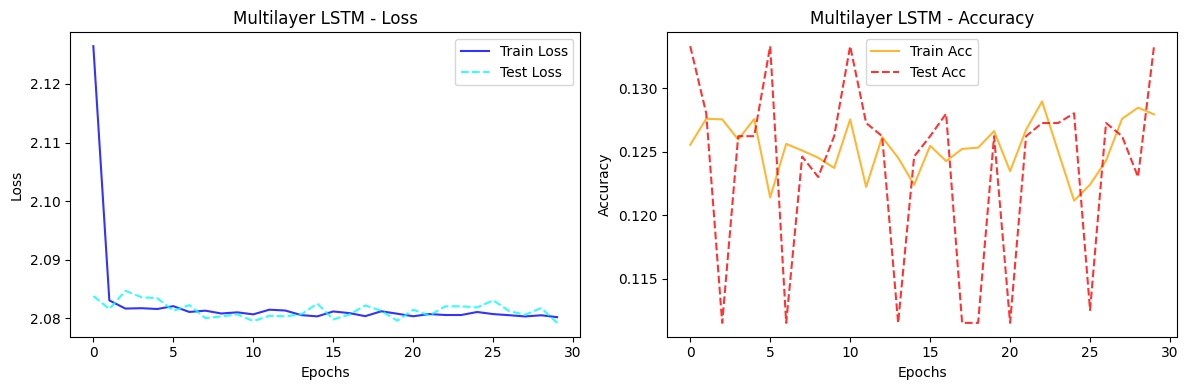

In [7]:
class MultilayerLSTM(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=EMBED_DIM, num_layers=NUM_LAYERS):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        # We need to specify batch_first=True so that this accepts
        # inputs in the format the task defined above accepts
        self.lstm = nn.LSTM(embed_dim, embed_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        # extract embeddings
        x = self.emb(x)
        # compute the output, but discard the hidden state
        out, _ = self.lstm(x)
        return self.fc(out)

print(f"\nTraining Multilayer LSTM ({DEFAULT_EPOCHS} Epochs)...")
model_lstm = SequenceTaskSystem(MultilayerLSTM())
trainer_lstm = pl.Trainer(max_epochs=DEFAULT_EPOCHS, accelerator="auto", enable_checkpointing=False, logger=False, num_sanity_val_steps=0)
trainer_lstm.fit(model_lstm, train_dataloaders=train_loader_copy, val_dataloaders=test_loader_copy)
plot_training_curves(model_lstm, "Multilayer LSTM")

> 📝 **Reflection 3**
>
> *Briefly comment on the results. Is the model learning? Is this accuracy good? What would be chance level? (see how it is computed in the code)*
>
> Your answer


### 🏗️ Model 2: Multilayer TCN
We saw that TCNs can reach very competitive results without using recurrence. Let's now implement a simple 2-layer 1D temporal convolutional netowrk.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



🔵 Training Multilayer TCN (30 Epochs)...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ MultilayerTCN    │ 26.0 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 26.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 26.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


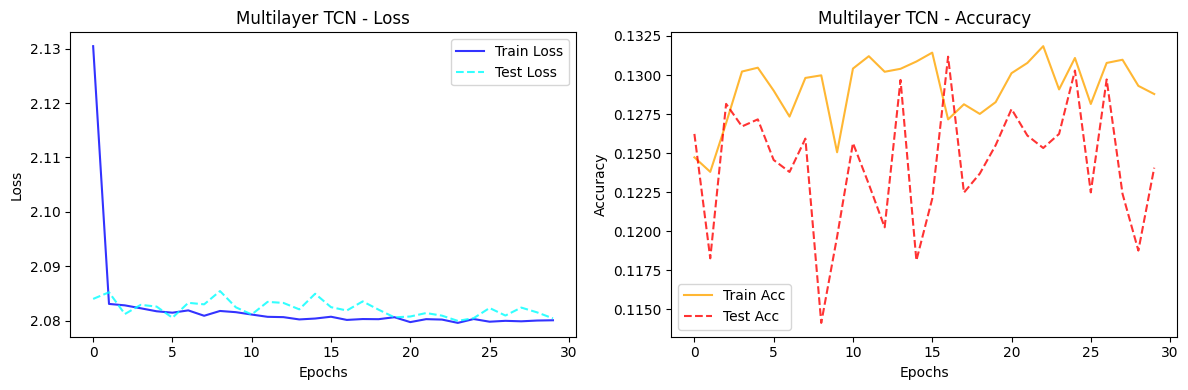

In [8]:
class CausalConv1d(nn.Module):
    def __init__(self, in_c, out_c, kernel_size, dilation=1):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_c, out_c, kernel_size, padding=self.pad, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.pad] if self.pad > 0 else x

class MultilayerTCN(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=EMBED_DIM):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.conv1 = CausalConv1d(embed_dim, embed_dim, kernel_size=3, dilation=1)
        self.conv2 = CausalConv1d(embed_dim, embed_dim, kernel_size=3, dilation=4)
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        x = self.emb(x).transpose(1, 2)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.transpose(1, 2)
        return self.fc(x)

print(f"\n🔵 Training Multilayer TCN ({DEFAULT_EPOCHS} Epochs)...")
model_tcn = SequenceTaskSystem(MultilayerTCN())
trainer_tcn = pl.Trainer(max_epochs=DEFAULT_EPOCHS, accelerator="auto", enable_checkpointing=False, logger=False, num_sanity_val_steps=0)
trainer_tcn.fit(model_tcn, train_dataloaders=train_loader_copy, val_dataloaders=test_loader_copy)
plot_training_curves(model_tcn, "Multilayer TCN")

> 📝 **Reflection 4**
>
> *Compare results with those of the LSTM. Is this model any better? Why? Could a deeper model work better than this?*
>
> Your answer


### 🏗️ Model 3: Standard Causal Transformer
Let's now implment a standard causal transformer, which performs standard self-attention plus a lower-triangular causal mask. This model computes interactions for every token pair, creating an $O(N^2)$ bottleneck.

Unlike RNNs (which process sequentially), Attention mechanisms process all tokens globally. Without an explicit sense of sequence order, Transformers treat inputs as a "bag of words." To fix this, we inject sinusoidal positional encodings to give Transformers a sense of time.

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term) #sine and cosine embeddings
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # Adds the token to the positional embedding
        return x + self.pe[:, :x.size(1), :]

Now let's implement the causal transformer. To do so, we need to define a causal mask, which can be done with the `nn.Transformer.generate_square_subsequent_mask` function:

In [13]:
nn.Transformer.generate_square_subsequent_mask(10)

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

> 📝 **Reflection 5**
>
> *How and why does this attention mask work? How is it used?*
>
> Your answer


> ☑️ **TODO 2**
>
> Implement the forward pass of the standard causal transformer:

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



🟠 Training Standard Causal Transformer (30 Epochs)...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ StandardCausalTransformer │  563 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss          │      0 │ train │     0 │
└───┴───────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 563 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 563 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 27                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


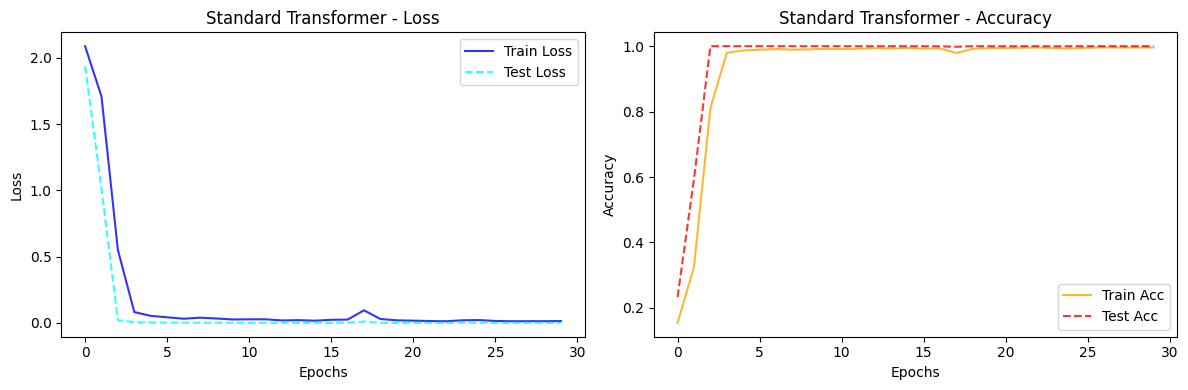

In [11]:
class StandardCausalTransformer(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=EMBED_DIM, num_layers=NUM_LAYERS):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_enc = PositionalEncoding(embed_dim)

        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=2, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        L = x.size(1) # get the sequence length
        mask = nn.Transformer.generate_square_subsequent_mask(L).to(x.device)

        # TODO: implement the following operations
        # project inputs x to embeddings
        # add positional encodings
        # pass the modified input to the transformer encoder using the causal mask
        # <YOUR CODE>
        
        # </YOUR CODE>
        return self.fc(x)

print(f"\n🟠 Training Standard Causal Transformer ({DEFAULT_EPOCHS} Epochs)...")
model_tf = SequenceTaskSystem(StandardCausalTransformer())
trainer_tf = pl.Trainer(max_epochs=DEFAULT_EPOCHS, accelerator="auto", enable_checkpointing=False, logger=False, num_sanity_val_steps=0)
trainer_tf.fit(model_tf, train_dataloaders=train_loader_copy, val_dataloaders=test_loader_copy)
plot_training_curves(model_tf, "Standard Transformer")

> 📝 **Reflection 6**
>
> *Compare results with those of previous trials and briefly comment. Is this working better? Why?*
>
> Your answer


### 🏗️ Model 4: Transformers are RNNs (Linear Attention)

Let's now implement a linear transformer using a $\phi(x) = \text{elu}(x) + 1$ representation function to rewrite self-attention without the Softmax operator.

By computing $Q(K^T V)$ with a causal mask, we can train the model in massively parallel $O(N^2)$ mode. However, mathematically, this model can be unrolled as an $O(1)$ recurrent model during inference!

> <b>☑️ TODO 3</b>
> Implement the parallel training mode for Linear Attention.
> You must compute the causal attention matrix, mask the future tokens, and multiply by $V$.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



🟢 Training Dual-Mode Linear Transformer (30 Epochs)...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ LinearTransformer │ 34.6 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 34.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 34.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


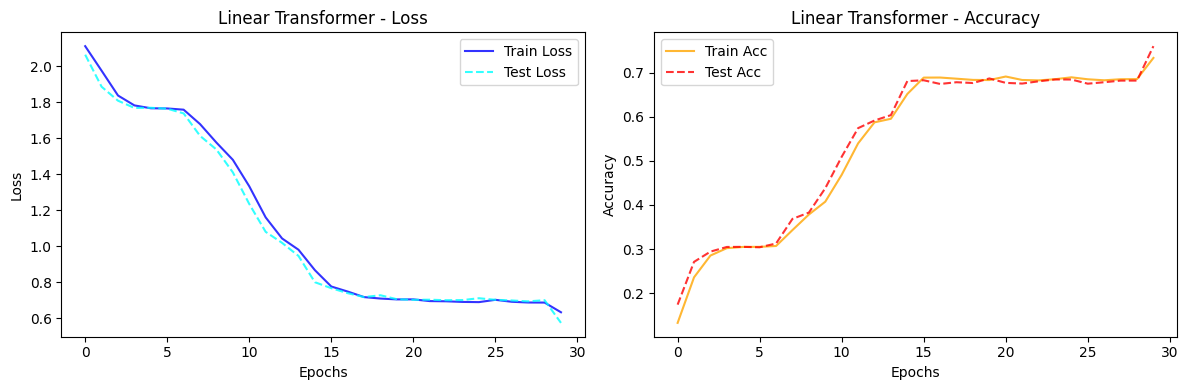

In [15]:
# The Linear Attention Layer
class LinearAttention(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        # a linear layer projecting to the concatenation of qkv
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        # the output linear layer
        self.out = nn.Linear(embed_dim, embed_dim)

    def phi(self, x):
        # TODO: Implement the phi representation function
        # <YOUR CODE>
        
        # </YOUR CODE>

    def forward(self, x):
        B, L, D = x.size() # batch, sequence length, dimension
        qkv = self.qkv(x) #project inputs to qkv
        q, k, v = torch.chunk(qkv, 3, dim=-1) # unpack to q, k, v

        # Apply the representation function
        q, k = self.phi(q), self.phi(k)

        # <YOUR CODE>
        # TODO: Compute the unnormalized N x N attention matrix (q * k^T)
        # HINT: q is (B, L, D) and k is (B, L, D). We want (B, L, L)
        # Using torch.bmm for batch matrix multiplication
        # Since we already applied the representation to q k and v
        # we only have to perform an inner product in matrix form
        # define attn = ...
        

        # TODO: Apply the Causal Mask
        # HINT: Multiply 'attn' by 0 for future tokens. Since there is no Softmax, do NOT use -inf!
        # HINT: look up torch.tril
        # define mask = ... and apply it to attn, so that it is "filtered"
        

        # TODO: Multiply by V and normalize the output (torch.bmm)
        # HINT: For the denominator, sum the attention weights over the sequence dimension (s) and add 1e-6 for stability
        
        # </YOUR CODE>

        return self.out(num / den)

# The two-layer implementation
class LinearTransformer(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=EMBED_DIM):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_enc = PositionalEncoding(embed_dim)

        self.layer1 = LinearAttention(embed_dim)
        self.layer2 = LinearAttention(embed_dim)
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        x = self.emb(x)
        x = self.pos_enc(x)
        x = self.layer1(x)
        x = self.layer2(x)
        return self.fc(x)

print(f"\n🟢 Training Dual-Mode Linear Transformer ({DEFAULT_EPOCHS} Epochs)...")
model_lin = SequenceTaskSystem(LinearTransformer())
trainer_lin = pl.Trainer(max_epochs=DEFAULT_EPOCHS, accelerator="auto", enable_checkpointing=False, logger=False, num_sanity_val_steps=0)
trainer_lin.fit(model_lin, train_dataloaders=train_loader_copy, val_dataloaders=test_loader_copy)
plot_training_curves(model_lin, "Linear Transformer")

> 📝 **Reflection 7**
>
> *How does the linear transformer work with respect to previous methods? Can training for longer improve performance?*
>
> Your answer


### 🏗️ Model 5: xLSTM (Extended LSTM)
We now comapre to the `xLSTM` architecture. We will use an architecture composed purely of `mLSTM` blocks. These parallel scans train blazingly fast on older GPUs compared to the sequential scalar blocks.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



🟤 Training pure mLSTM on Copy Memory (30 Epochs)...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ xLSTMSequenceClassifier │ 57.0 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss        │      0 │ train │     0 │
└───┴───────────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 57.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 57.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 41                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


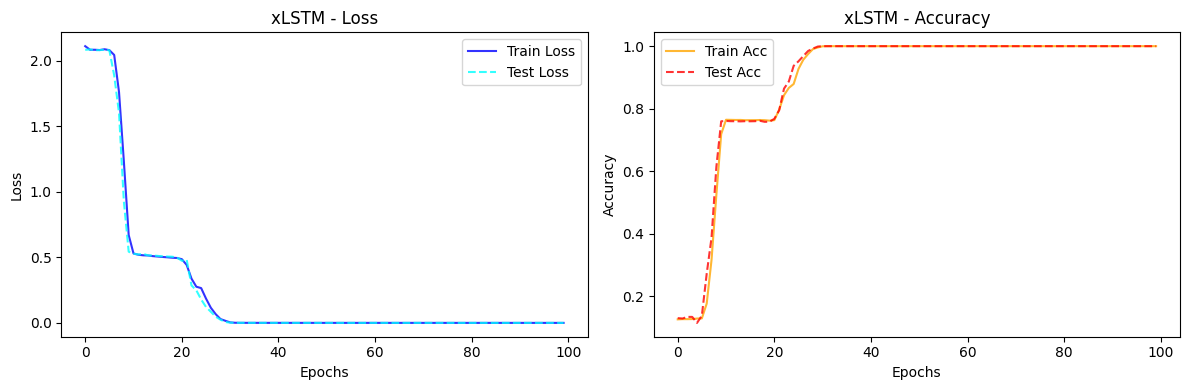

In [18]:
try:
    from xlstm import (xLSTMBlockStack, xLSTMBlockStackConfig, mLSTMBlockConfig,
                       sLSTMBlockConfig, mLSTMLayerConfig, sLSTMLayerConfig)

    class xLSTMSequenceClassifier(nn.Module):
        def __init__(self, vocab_size=10, embed_dim=EMBED_DIM):
            super().__init__()
            self.emb = nn.Embedding(vocab_size, embed_dim)
            cfg = xLSTMBlockStackConfig(
                mlstm_block=mLSTMBlockConfig(mlstm=mLSTMLayerConfig(conv1d_kernel_size=4, qkv_proj_blocksize=4, num_heads=1)),
                slstm_block=sLSTMBlockConfig(slstm=sLSTMLayerConfig(num_heads=1, conv1d_kernel_size=4, backend="vanilla")),
                context_length=SEQ_LEN,
                num_blocks=NUM_LAYERS,
                embedding_dim=embed_dim,
                slstm_at=[] # Purely mLSTM blocks for fast parallel hardware utilization
            )
            self.xlstm = xLSTMBlockStack(cfg)
            self.fc = nn.Linear(embed_dim, vocab_size)

        def forward(self, x):
            x = self.emb(x)
            x = self.xlstm(x)
            return self.fc(x)

    print(f"\n🟤 Training pure mLSTM on Copy Memory ({DEFAULT_EPOCHS} Epochs)...")
    model_xlstm = SequenceTaskSystem(xLSTMSequenceClassifier())
    trainer_xlstm = pl.Trainer(max_epochs=XLSTM_EPOCHS, accelerator="auto", enable_checkpointing=False, logger=False, num_sanity_val_steps=0)
    trainer_xlstm.fit(model_xlstm, train_dataloaders=train_loader_copy, val_dataloaders=test_loader_copy)
    plot_training_curves(model_xlstm, "xLSTM")

except ImportError as e:
    print(f"⚠️ xlstm module missing. Error: {e}")

> 📝 **Reflection 8**
>
> *How does xLSTM compare with respect to previous methods? Why?*
>
> Your answer


### 🏆 Final Accuracy Comparison

In [19]:
print("\n" + "="*40)
print("🏆 FINAL TEST ACCURACY COMPARISON 🏆")
print("="*40)
for model_name, acc in final_accuracies.items():
    print(f"{model_name:<25}: {acc*100:.2f}%")
print("="*40)


🏆 FINAL TEST ACCURACY COMPARISON 🏆
Multilayer LSTM          : 13.33%
Multilayer TCN           : 12.41%
Standard Transformer     : 100.00%
Linear Transformer       : 76.01%
xLSTM                    : 100.00%


> 📝 **Reflection 9**
>
> *Reflect on the final results. Which model is best? Why? What trade-offs are we seeing in action?*
>
> Your answer

## ⏱️ The Reality Check: Autoregressive Speed on CPU
Accuracy is only half the battle. When deploying models in the real world for text generation, they must run **autoregressively** (predicting token-by-token).

In this final test, we strip away all parallel GPU tricks and force the models to generate sequences step-by-step on the CPU.
* **RNNs (LSTM, TCN, Linear Attn, xLSTM):** Maintain a fixed-size state buffer. Generating the 1st token should take the same amount of math as the 1000th token ($O(1)$).
* **Transformers:** Must maintain a growing KV Cache. Generating the 1000th token requires calculating attention across 1000 past vectors ($O(N)$).



Run the cell below to empirically verify their true algorithmic complexity!

In [ ]:
import time
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Disable multi-threading to measure pure algorithmic overhead
torch.set_num_threads(1)

# Stateful architecture wrappers for O(1) step testing
class StatefulLSTM(nn.Module):
    def __init__(self, d_model=EMBED_DIM):
        super().__init__()
        self.cell1 = nn.LSTMCell(d_model, d_model)
        self.cell2 = nn.LSTMCell(d_model, d_model)

    def step(self, x_t, state):
        if state is None:
            B = x_t.size(0)
            state = [(torch.zeros(B, EMBED_DIM), torch.zeros(B, EMBED_DIM)) for _ in range(2)]
        h1, c1 = self.cell1(x_t.squeeze(1), state[0])
        h2, c2 = self.cell2(h1, state[1])
        return h2.unsqueeze(1), [(h1, c1), (h2, c2)]

class StatefulTCN(nn.Module):
    def __init__(self, d_model=EMBED_DIM):
        super().__init__()
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size=3, dilation=1)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size=3, dilation=4)
        self.receptive_field = 11

    def step(self, x_t, buffer):
        B, _, D = x_t.size()
        if buffer is None:
            buffer = torch.zeros(B, D, self.receptive_field)
        buffer = torch.cat([buffer[:, :, 1:], x_t.transpose(1, 2)], dim=2)
        x = torch.relu(self.conv1(buffer))
        x = torch.relu(self.conv2(x))
        return x[:, :, -1:].transpose(1, 2), buffer

class StatefulStandardTransformer(nn.Module):
    def __init__(self, d_model=EMBED_DIM):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d_model, d_model * 3) for _ in range(NUM_LAYERS)])
        self.proj = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(NUM_LAYERS)])
        self.scale = math.sqrt(d_model)

    def step(self, x_t, kv_caches):
        if kv_caches is None:
            kv_caches = [None] * NUM_LAYERS
        new_caches = []
        for i, (qkv_proj, out_proj) in enumerate(zip(self.layers, self.proj)):
            qkv = qkv_proj(x_t)
            q, k, v = torch.chunk(qkv, 3, dim=-1)
            if kv_caches[i] is not None:
                K, V = torch.cat([kv_caches[i][0], k], dim=1), torch.cat([kv_caches[i][1], v], dim=1)
            else:
                K, V = k, v
            new_caches.append((K, V))
            attn = torch.softmax(torch.bmm(q, K.transpose(1, 2)) / self.scale, dim=-1)
            x_t = out_proj(torch.bmm(attn, V))
        return x_t, new_caches

class StatefulLinearTransformer(nn.Module):
    def __init__(self, d_model=EMBED_DIM):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d_model, d_model * 3) for _ in range(NUM_LAYERS)])
        self.proj = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(NUM_LAYERS)])

    def phi(self, x): return F.elu(x) + 1.0

    def step(self, x_t, states):
        B, _, D = x_t.size()
        if states is None:
            states = [(torch.zeros(B, D, D), torch.zeros(B, D)) for _ in range(NUM_LAYERS)]
        new_states = []
        for i, (qkv_proj, out_proj) in enumerate(zip(self.layers, self.proj)):
            S, Z = states[i]
            qkv = qkv_proj(x_t)
            q, k, v = torch.chunk(qkv, 3, dim=-1)
            q_i, k_i, v_i = self.phi(q).squeeze(1), self.phi(k).squeeze(1), v.squeeze(1)

            Z, S = Z + k_i, S + torch.einsum('bd,bc->bdc', k_i, v_i)
            num, den = torch.einsum('bd,bdc->bc', q_i, S), torch.einsum('bd,bd->b', q_i, Z).unsqueeze(-1) + 1e-6
            x_t = out_proj(num / den).unsqueeze(1)
            new_states.append((S, Z))
        return x_t, new_states

class StatefulmLSTM(nn.Module):
    def __init__(self, d_model=EMBED_DIM):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d_model, d_model * 3) for _ in range(NUM_LAYERS)])
        self.proj = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(NUM_LAYERS)])

    def step(self, x_t, states):
        B, _, D = x_t.size()
        if states is None:
            states = [(torch.zeros(B, D, D), torch.zeros(B, D)) for _ in range(NUM_LAYERS)]
        new_states = []
        for i, (qkv_proj, out_proj) in enumerate(zip(self.layers, self.proj)):
            C, N = states[i]
            q, k, v = torch.chunk(qkv_proj(x_t), 3, dim=-1)
            q_i, k_i, v_i = q.squeeze(1), k.squeeze(1), v.squeeze(1)

            C, N = C + torch.einsum('bd,bc->bdc', v_i, k_i), N + k_i
            num, den = torch.einsum('bd,bdc->bc', q_i, C), torch.einsum('bd,bd->b', q_i, N).unsqueeze(-1) + 1e-6
            x_t = out_proj(num / den).unsqueeze(1)
            new_states.append((C, N))
        return x_t, new_states

# Benchmarking Loop
print("🚀 Running CPU Autoregressive Benchmark...")
seq_lengths = [64, 128, 256, 512, 1024]
models = {
    "LSTM": StatefulLSTM(), "TCN": StatefulTCN(),
    "Linear Transformer": StatefulLinearTransformer(), "xLSTM (mLSTM)": StatefulmLSTM(),
    "Standard Transformer": StatefulStandardTransformer()
}
results = {name: [] for name in models.keys()}

for L in seq_lengths:
    for name, model in models.items():
        model.eval()
        dummy_input = torch.randn(16, L, EMBED_DIM)

        state = None
        for t in range(5): _, state = model.step(dummy_input[:, t:t+1, :], state) # Warmup

        state = None
        start = time.time()
        for t in range(L): _, state = model.step(dummy_input[:, t:t+1, :], state)
        total_time_ms = (time.time() - start) * 1000

        # Calculate Time Per Token!
        results[name].append(total_time_ms / L)

# Plotting
plt.figure(figsize=(9, 6))
for (name, times), marker in zip(results.items(), ['o', 's', 'D', 'v', '^']):
    plt.plot(seq_lengths, times, marker=marker, label=name, linewidth=2)

plt.title("Autoregressive Inference on CPU (Time Per Token)", fontsize=14)
plt.xlabel("Sequence Length (Tokens)", fontsize=12)
plt.ylabel("Time to Generate 1 Token (ms)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Restore multi-threading
torch.set_num_threads(torch.get_num_threads())

> 📝 **Reflection 10**
>
> *Comment the plot above. Which models have a linear computation with respect to inputs? Why? What are the trade-offs?*
>
> Your answer

## 🚀 Extensions and Homework

### 💡 Further Experimentation

1.  **Parameter Optimization:** The models were constrained to a similar parameter count for a fair initial comparison. Experiment with different `EMBED_DIM` and `NUM_LAYERS` values for each model to see how they scale. Consider using hyperparameter tuning techniques.
2.  **Longer Training:** Some models, like xLSTM, are noted to converge slower on synthetic tasks. For a truly fair comparison, consider training all models for a longer duration (e.g., `XLSTM_EPOCHS`) or until their validation accuracy plateaus.
3.  **Different Architectures:** Explore other sequential modeling architectures not covered in this lab, such as S4, RULER, or even different variants of Transformers (e.g., Reformer, Performer).
4.  **Real-world Data:** Test the implemented models on a real-world sequential dataset (e.g., text classification, time series prediction) to observe their performance outside of a synthetic task.

### 📝 Exercises

1.  **Implement Positional Encoding for RNNs/TCNs:** While not strictly necessary for RNNs and TCNs due to their inherent sequential processing, experiment with adding positional encodings to the LSTM and TCN models. How does this affect their performance on the Copy Memory Task? Explain your observations.
2.  **Vary `T_COPY`:** Change the `T_COPY` parameter (the duration of blank tokens) to significantly larger values (e.g., 256, 512, 1024). Re-run the benchmarks. Which models maintain their accuracy and efficiency? Which ones struggle, and why?
3.  **Analyze Attention Patterns:** For the Standard and Linear Transformers, try to visualize the attention weights on some example sequences. Can you observe how they retrieve information from the beginning of the sequence after the delay period?
4.  **Implement a different `phi` function for Linear Attention:** The current `phi` function is `F.elu(x) + 1.0`. Research other possible non-negative kernel functions and implement one. How does it affect the model's performance and stability?


---
**Submission:**
Please wrap up your code, ensure your WandB logs are synced (include the link in your notebook), and submit your `.ipynb` file via email.